# YouTube Videó Sikeresség Predikció – Random Forest Osztályozó

**Cél:** Megjósolni, hogy egy YouTube trending videó sikeresnek tekinthető-e
a videóhoz kapcsolódó metaadatok és korai engagement jelek alapján.

**Dataset:** [Kaggle – YouTube New Trending Dataset](https://www.kaggle.com/datasets/datasnaek/youtube-new)
**Fájl:** `GBvideos.csv` (Nagy-Britannia trending videói)

---

## Tartalomjegyzék
1. [Adatbetöltés](#1)
2. [Feltáró adatelemzés (EDA)](#2)
3. [Adattisztítás](#3)
4. [Feature Engineering](#4)
5. [Célváltozó meghatározása](#5)
6. [Feature kiválasztás és szivárgás-elemzés](#6)
7. [Vizualizációk](#7)
8. [Modellépítés](#8)
9. [Hiperparaméter hangolás](#9)
10. [Kiértékelés](#10)
11. [Feature Importance](#11)
12. [Összefoglalás](#12)

## 1. Adatbetöltés <a id='1'></a>

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import json as json_lib
import warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("datasnaek/youtube-new")
print("Dataset elérési út:", path)

C:\Users\pocsa\PycharmProjects\gepiProj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset elérési út: C:\Users\pocsa\.cache\kagglehub\datasets\datasnaek\youtube-new\versions\115


In [2]:
df = pd.read_csv(os.path.join(path, "GBvideos.csv"))
print(f"Sorok: {len(df):,}  |  Oszlopok: {df.shape[1]}")
df.head(3)

Sorok: 38,916  |  Oszlopok: 16


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...
1,3s1rvMFUweQ,17.14.11,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs …Ready for...
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38916 entries, 0 to 38915
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                38916 non-null  str  
 1   trending_date           38916 non-null  str  
 2   title                   38916 non-null  str  
 3   channel_title           38916 non-null  str  
 4   category_id             38916 non-null  int64
 5   publish_time            38916 non-null  str  
 6   tags                    38916 non-null  str  
 7   views                   38916 non-null  int64
 8   likes                   38916 non-null  int64
 9   dislikes                38916 non-null  int64
 10  comment_count           38916 non-null  int64
 11  thumbnail_link          38916 non-null  str  
 12  comments_disabled       38916 non-null  bool 
 13  ratings_disabled        38916 non-null  bool 
 14  video_error_or_removed  38916 non-null  bool 
 15  description             38304 

## 2. Feltáró adatelemzés (EDA) <a id='2'></a>

Megnézzük a numerikus oszlopok alapstatisztikáit és a hiányzó értékeket,
hogy informált döntéseket hozhassunk az előfeldolgozás során.

In [4]:
df.describe().round(2)

,category_id,views,likes,dislikes,comment_count
count,38916.00,3.891600e+04,38916.00,38916.00,38916.00
mean,16.83,5.911944e+06,134519.55,7612.56,13088.35
std,7.75,1.900121e+07,349989.31,50956.83,50667.40
min,1.00,8.510000e+02,0.00,0.00,0.00
25%,10.00,2.515272e+05,5897.00,200.00,679.00
50%,20.00,9.818890e+05,25182.50,821.00,2478.00
75%,24.00,3.683628e+06,114089.25,3357.50,9241.50
max,43.00,4.245389e+08,5613827.00,1944971.00,1626501.00


In [5]:
print("Hiányzó értékek oszloponként:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDuplikált sorok: {df.duplicated().sum()}")

Hiányzó értékek oszloponként:
description    612
dtype: int64

Duplikált sorok: 171


## 3. Adattisztítás <a id='3'></a>

### Döntések és indoklásuk

| Lépés | Indoklás |
|-------|----------|
| `description` NaN → `''` | A leírás hossza fontos feature lesz; NaN helyett üres string → `desc_length = 0` |
| Duplikátumok eltávolítása | Ugyanaz a videó többször is felkerülhet a trendinglistára; az engagement adatok torzítanák a modellt |
| `video_id`, `channel_title`, `thumbnail_link` törlése | Egyedi azonosítók – nem általánosítható jellemzők |
| `tags` → `[none]` kezelése | Az üres tagek jelzése egységesítve |
| Boolean oszlopok → int | Scikit-learn kompatibilitás |

In [6]:
# Hiányzó description kitöltése üres stringgel
df['description'] = df['description'].fillna('')

# Duplikátumok eltávolítása
before = len(df)
df = df.drop_duplicates()
print(f"Duplikátumok eltávolítva: {before - len(df)} sor")

# Nem hasznos oszlopok törlése
df = df.drop(columns=['video_id', 'channel_title', 'thumbnail_link'])

# Boolean → int
for col in ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']:
    df[col] = df[col].astype(int)

# Tags egységesítés
df['tags'] = df['tags'].replace('[none]', '')

print(f"Tisztított adathalmaz mérete: {len(df):,} sor")

Duplikátumok eltávolítva: 171 sor
Tisztított adathalmaz mérete: 38,745 sor


## 4. Feature Engineering <a id='4'></a>

### 4.1 Dátum- és időbeli jellemzők

A publikálás időpontjából kinyerjük az óra, napszak és szezonális mintázatokat.
A `publish_time` normalize() előtt nyerjük ki az órát – utána az időzóna-adat elvész.

In [7]:
df['publish_time'] = pd.to_datetime(df['publish_time'])

# Óra kinyerése NORMALIZE előtt
df['publish_hour']      = df['publish_time'].dt.hour
df['publish_dayofweek'] = df['publish_time'].dt.dayofweek   # 0=Hétfő
df['publish_month']     = df['publish_time'].dt.month
df['publish_is_weekend'] = df['publish_dayofweek'].isin([5, 6]).astype(int)

# Normalize + timezone strip
df['publish_time'] = df['publish_time'].dt.normalize().dt.tz_localize(None)

# Trending dátum
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m').dt.normalize()

# Hány nappal a feltöltés után trendelt
df['days_to_trend'] = (df['trending_date'] - df['publish_time']).dt.days

print("Dátum feature-ök elkészültek.")
df[['publish_hour', 'publish_dayofweek', 'publish_month', 'days_to_trend']].describe().round(2)

Dátum feature-ök elkészültek.


,publish_hour,publish_dayofweek,publish_month,days_to_trend
count,38745.00,38745.00,38745.00,38745.00
mean,12.94,2.58,5.39,36.89
std,6.45,1.74,4.14,241.99
min,0.00,0.00,1.00,0.00
25%,8.00,1.00,2.00,6.00
50%,15.00,3.00,4.00,10.00
75%,18.00,4.00,11.00,18.00
max,23.00,6.00,12.00,3990.00


### 4.2 Cím-alapú jellemzők

A cím szövege fontos signal – a clickbait elemek (nagybetűk, felkiáltójelek, számok)
összefügghetnek a kattintási arányokkal.

In [8]:
df['title_length']      = df['title'].str.len()
df['title_word_count']  = df['title'].str.split().str.len()

# Nagybetűs szavak aránya (0.0–1.0)
df['title_caps_ratio']  = df['title'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper()) / max(len(str(x).split()), 1)
)

# Írásjel-alapú clickbait jelzők
df['title_exclamation'] = df['title'].str.count('!').astype(int)
df['title_question']    = df['title'].str.count(r'\?').astype(int)
df['title_has_number']  = df['title'].str.contains(r'\d').astype(int)

print("Cím feature-ök elkészültek.")

Cím feature-ök elkészültek.


### 4.3 Tag és leírás jellemzők

In [9]:
df['tag_count']    = df['tags'].apply(lambda x: 0 if x == '' else len(str(x).split('|')))
df['desc_length']  = df['description'].str.len()

print("Tag és leírás feature-ök elkészültek.")

Tag és leírás feature-ök elkészültek.


### 4.4 Engagement jellemzők

**Fontos döntés – mit tartunk meg és mit nem:**

| Feature | Megtartva? | Indoklás |
|---------|-----------|----------|
| `likes`, `dislikes`, `comment_count` | ✅ Igen | Korai engagement jelzők; **nem tartalmazzák a `views` értékét** |
| `like_dislike_ratio` | ✅ Igen | A videó fogadtatásának minőségi mutatója, szivárgásmentes |
| `like_rate = likes/(views+1)` | ❌ Nem | **`views` van a nevezőben** → közvetlen szivárgás |
| `dislike_rate`, `comment_rate` | ❌ Nem | Ugyanaz – views a nevező |

> A `likes`/`dislikes` önmagában korrelál a `views`-szal (népszerű videók több like-ot kapnak),
> de ez **valós predikciós összefüggés**, nem technikai szivárgás.

In [10]:
df['like_dislike_ratio'] = df['likes'] / (df['dislikes'] + 1)

print("Engagement feature-ök elkészültek.")
print(f"\nDataFrame mérete: {df.shape}")

Engagement feature-ök elkészültek.

DataFrame mérete: (38745, 27)


## 5. Célváltozó meghatározása <a id='5'></a>

Mivel az adathalmaz **kizárólag trending videókat** tartalmaz, hagyományos
"sikeres vs. nem sikeres" felosztás nem lehetséges. Ezért a sikerességet
**relatívan definiáljuk** a megtekintések mediánja alapján:

$$\text{is\_successful} = \begin{cases} 1 & \text{ha } views > \text{medián} \\ 0 & \text{egyébként} \end{cases}$$

**Miért medián és nem átlag?**
A `views` eloszlása erősen jobbra ferde (néhány videó extrém magas értékkel).
A medián robusztus ezzel szemben, és pontosan 50-50%-os osztályarányt garantál.

In [11]:
threshold = df['views'].median()
df['is_successful'] = (df['views'] > threshold).astype(int)

print(f"Medián küszöb: {threshold:,.0f} megtekintés")
print()
print(df['is_successful'].value_counts())
print()
print(f"Osztályarány: {df['is_successful'].mean():.3f} (ideális: 0.500)")

Medián küszöb: 979,949 megtekintés

is_successful
0    19373
1    19372
Name: count, dtype: int64

Osztályarány: 0.500 (ideális: 0.500)


## 6. Feature kiválasztás és szivárgás-elemzés <a id='6'></a>

### Data leakage – miért kritikus?

Az adatszivárgás (data leakage) akkor lép fel, ha a feature-ök a **célváltozó
információját kódolják** – a modell így nem tanul valódi összefüggéseket,
csak a célváltozót "olvassa vissza".

**Jelen esetben:**
- Célváltozó: `is_successful = (views > medián)`
- Szivárgó feature-ök: minden ami `views`-t tartalmaz a számításában

### A kiválasztott feature-ök és döntések

| Feature | Csoport | Miért optimális? |
|---------|---------|-----------------|
| `category_id` | Kategória | A videó témája erős előrejelző |
| `publish_hour` | Időbeli | Reggel 8–11 és este 18–22 magasabb engagement |
| `publish_dayofweek` | Időbeli | Hétvégén vs. hétköznapon eltérő nézettség |
| `publish_month` | Időbeli | Szezonális hatások (karácsony, nyár stb.) |
| `publish_is_weekend` | Időbeli | Bináris összefoglalás a napszakhoz |
| `days_to_trend` | Trending | Gyorsabban trendő videók erősebb virális potenciállal bírnak |
| `title_length` | Cím | Optimális cím hossz |
| `title_word_count` | Cím | Szószám a figyelemfelkeltésben |
| `title_caps_ratio` | Cím | Clickbait mutató |
| `title_exclamation` | Cím | Érzelmi töltet |
| `title_question` | Cím | Kíváncsiságot keltő kérdések |
| `title_has_number` | Cím | "Top 10"-típusú listicle signal |
| `tag_count` | Metadata | SEO optimalizáltság jelzője |
| `desc_length` | Metadata | Gondosan megírt leírás = professzionálisabb csatorna |
| `likes` | Engagement | Pozitív visszajelzés volumene |
| `dislikes` | Engagement | Negatív visszajelzés volumene |
| `comment_count` | Engagement | Diskurzust generáló tartalom |
| `like_dislike_ratio` | Engagement | Fogadtatás minőségi mutatója |
| `comments_disabled` | Beállítás | Tiltott komment gyanúsabb / kisebb engagement |
| `ratings_disabled` | Beállítás | Tiltott értékelés – pl. vitatott tartalom |

> ⚠️ **`views` és a belőle képzett arányok (`like_rate` stb.) nem szerepelnek** –
> ezek közvetlenül a célváltozót kódolják.

In [12]:
features = [
    # Kategória
    'category_id',
    # Időbeli
    'publish_hour', 'publish_dayofweek', 'publish_month', 'publish_is_weekend',
    'days_to_trend',
    # Cím
    'title_length', 'title_word_count', 'title_caps_ratio',
    'title_exclamation', 'title_question', 'title_has_number',
    # Metadata
    'tag_count', 'desc_length',
    # Engagement (szivárgásmentes)
    'likes', 'dislikes', 'comment_count', 'like_dislike_ratio',
    # Beállítások
    'comments_disabled', 'ratings_disabled'
]

X = df[features].copy()
y = df['is_successful']

print(f"Feature-ök száma: {len(features)}")
print(f"Minták száma:     {len(X):,}")
print(f"Hiányzó értékek: {X.isnull().sum().sum()}")

Feature-ök száma: 20
Minták száma:     38,745
Hiányzó értékek: 0


## 7. Vizualizációk <a id='7'></a>

### Viz 1 – Célváltozó eloszlása

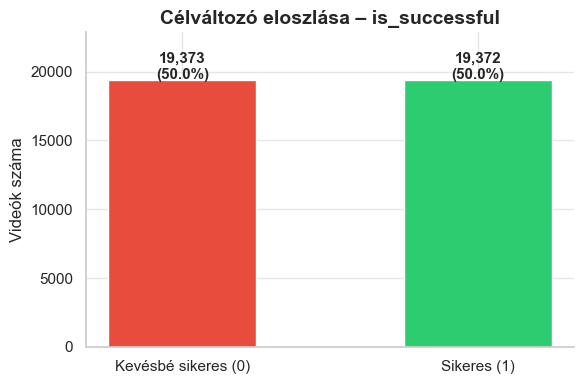

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['is_successful'].value_counts()
bars = ax.bar(['Kevésbé sikeres (0)', 'Sikeres (1)'], counts.values,
              color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 80,
            f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Célváltozó eloszlása – is_successful', fontsize=14, fontweight='bold')
ax.set_ylabel('Videók száma')
ax.set_ylim(0, max(counts.values) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Viz 2 – Views eloszlása és a medián küszöb

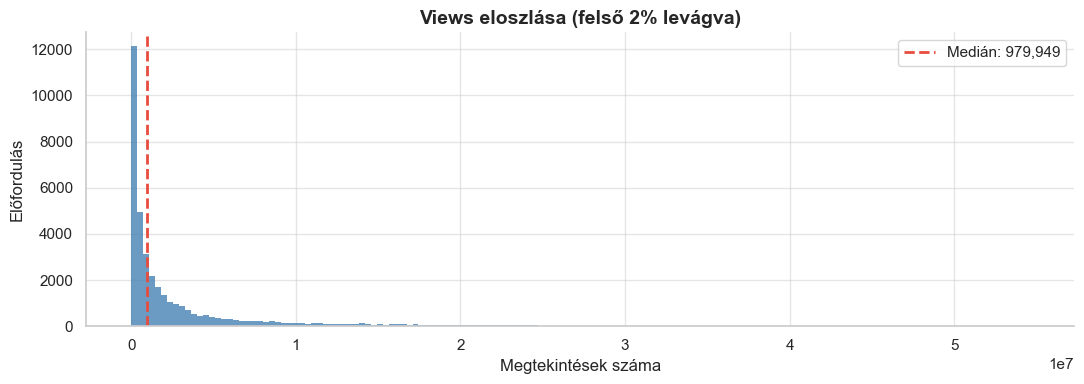

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
clip_val = df['views'].quantile(0.98)
ax.hist(df[df['views'] <= clip_val]['views'], bins=150,
        color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(threshold, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Medián: {threshold:,.0f}')
ax.set_title('Views eloszlása (felső 2% levágva)', fontsize=14, fontweight='bold')
ax.set_xlabel('Megtekintések száma')
ax.set_ylabel('Előfordulás')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Viz 3 – Korrelációs heatmap

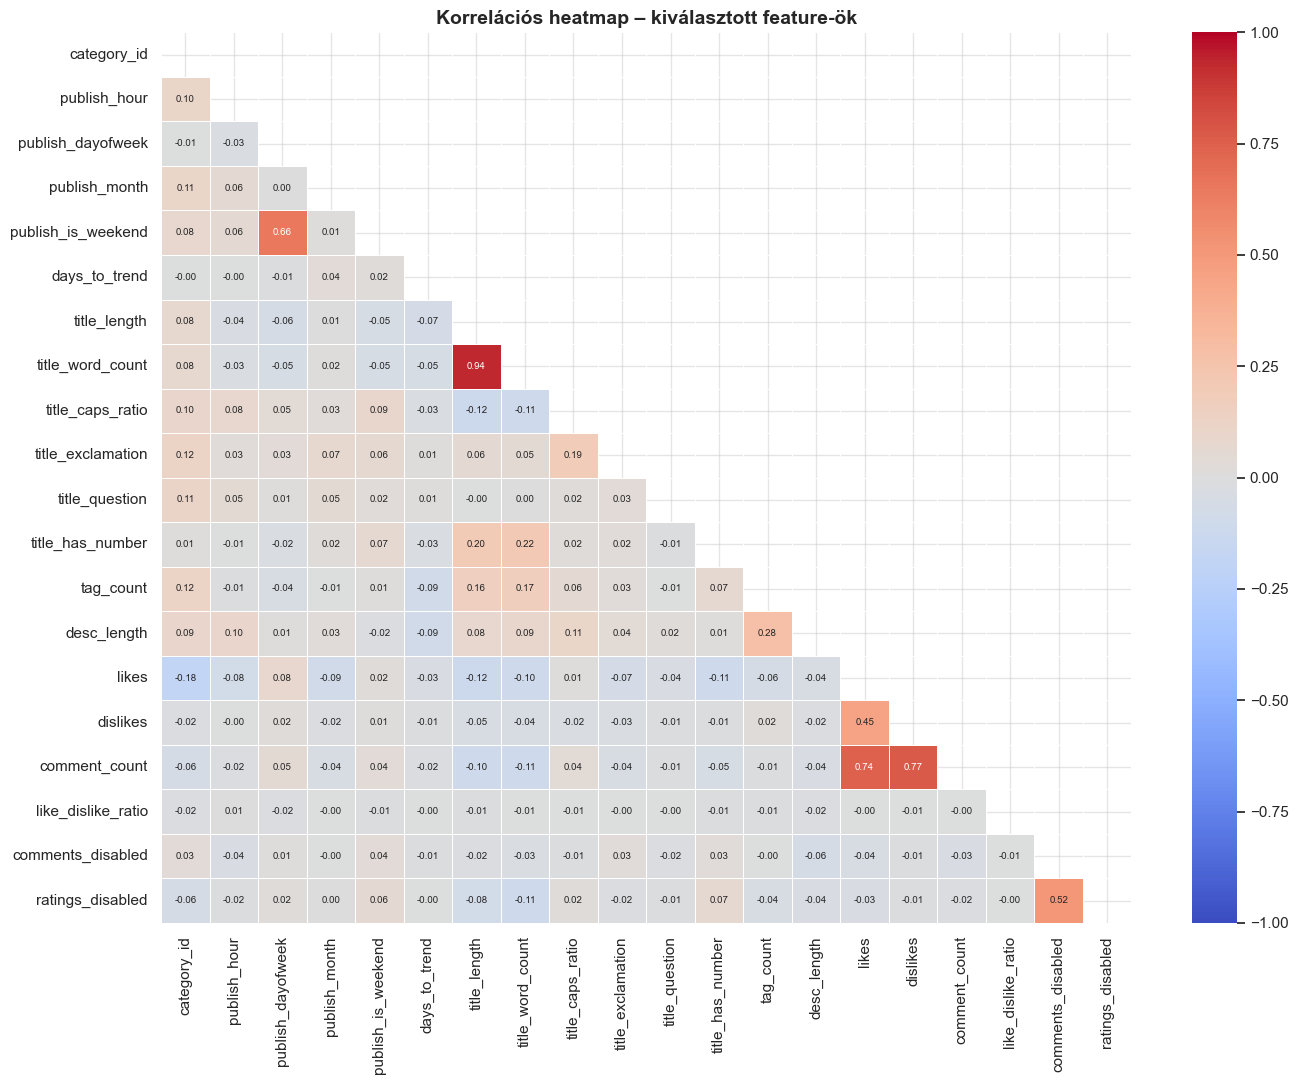

In [15]:
numeric_features = [f for f in features if df[f].dtype in ['int64','float64','int32']]
corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True          # csak alsó háromszög
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1)
ax.set_title('Korrelációs heatmap – kiválasztott feature-ök', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Viz 4 – Views eloszlása kategóriánként

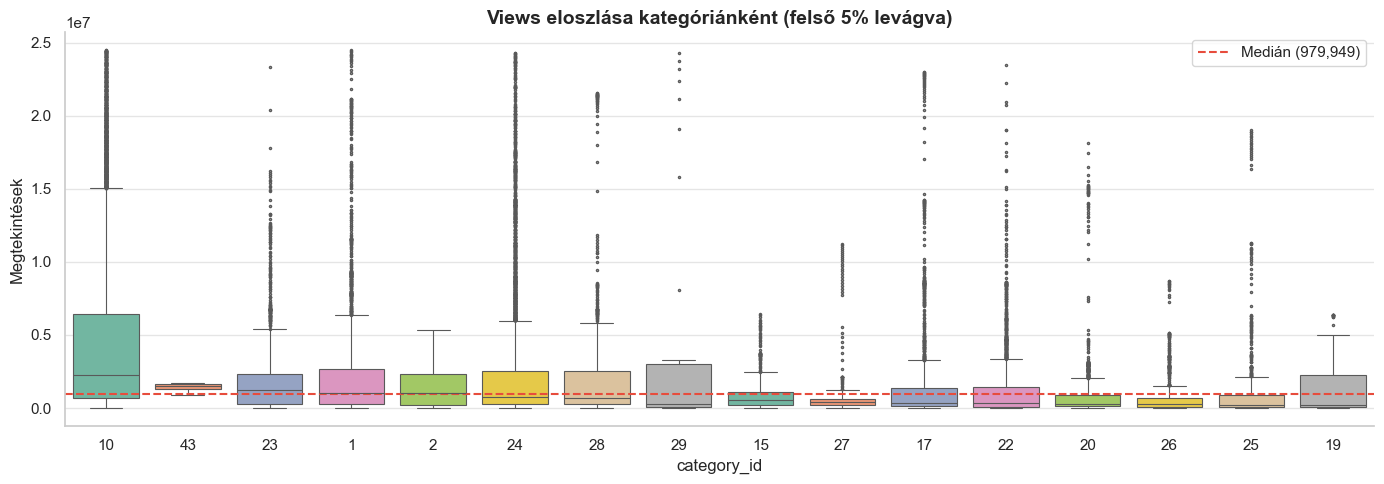

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
clip95 = df['views'].quantile(0.95)
cat_order = (df.groupby('category_id')['views']
               .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=df[df['views'] <= clip95],
            x='category_id', y='views', order=cat_order,
            palette='Set2', fliersize=1.5, ax=ax, linewidth=0.8)
ax.axhline(threshold, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Medián ({threshold:,.0f})')
ax.set_title('Views eloszlása kategóriánként (felső 5% levágva)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('category_id')
ax.set_ylabel('Megtekintések')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Viz 5 – Feltöltés órája és sikeresség

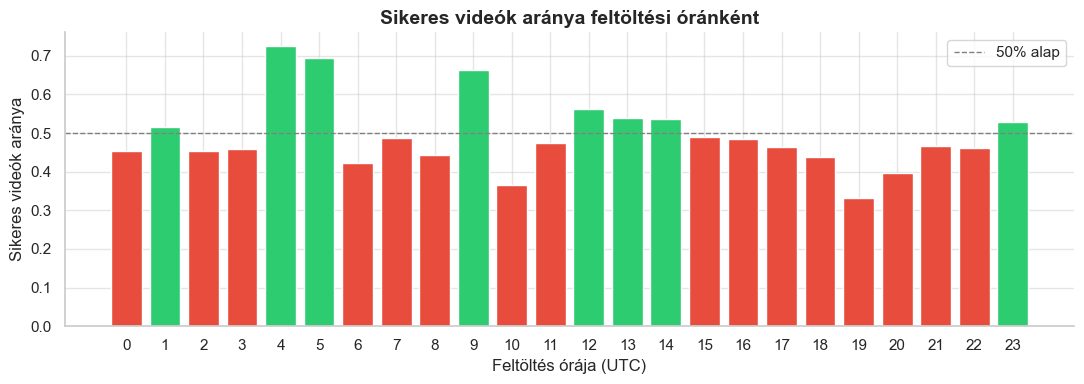

In [17]:
hourly = df.groupby('publish_hour')['is_successful'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hourly['publish_hour'], hourly['is_successful'],
       color=['#2ecc71' if v >= 0.5 else '#e74c3c' for v in hourly['is_successful']],
       edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% alap')
ax.set_title('Sikeres videók aránya feltöltési óránként', fontsize=14, fontweight='bold')
ax.set_xlabel('Feltöltés órája (UTC)')
ax.set_ylabel('Sikeres videók aránya')
ax.set_xticks(range(0, 24))
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Viz 6 – Likes és Days-to-trend eloszlása sikeresség szerint

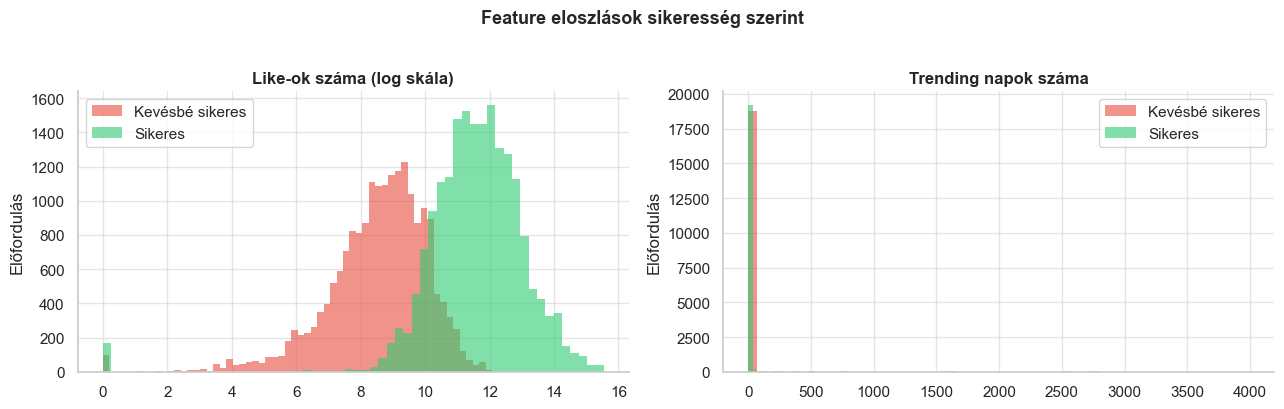

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in zip(axes,
        ['likes', 'days_to_trend'],
        ['Like-ok száma (log skála)', 'Trending napok száma']):
    for val, color, lbl in [(0, '#e74c3c', 'Kevésbé sikeres'), (1, '#2ecc71', 'Sikeres')]:
        data = df[df['is_successful'] == val][col]
        if col == 'likes':
            data = np.log1p(data)
        ax.hist(data, bins=60, alpha=0.6, color=color, label=lbl, edgecolor='none')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Előfordulás')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature eloszlások sikeresség szerint', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Modellépítés <a id='8'></a>

### Train / Test split

`stratify=y` biztosítja, hogy mindkét halmazban azonos arányban szerepeljenek
az osztályok – fontos egyensúlyi célváltozónál is.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} minta  |  Test: {len(X_test):,} minta")
print(f"Train class balance: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}")

Train: 30,996 minta  |  Test: 7,749 minta
Train class balance: 0.500  |  Test: 0.500


### Alap Random Forest

100 fával, párhuzamos futtatással. Ez adja a kiindulópontot a hangoláshoz.

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
print("Alap modell tanítása kész.")

Alap modell tanítása kész.


## 9. Hiperparaméter hangolás <a id='9'></a>

### RandomizedSearchCV

**Miért Randomized és nem Grid Search?**
A Grid Search exponenciálisan nő a paraméterek számával. A RandomizedSearchCV
véletlenszerűen mintáz a paramétertérből – az irodalom szerint 60 iteráció
kb. 95%-os valószínűséggel megtalálja az optimum közelébe eső megoldást,
töredék idő alatt.

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20, 30],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print("\nLegjobb paraméterek:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nLegjobb CV F1 (weighted): {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Legjobb paraméterek:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: 30

Legjobb CV F1 (weighted): 0.9842


In [22]:
rf_best = search.best_estimator_
print("Legjobb modell:", rf_best)

Legjobb modell: RandomForestClassifier(max_depth=30, max_features='log2', n_estimators=200,
                       n_jobs=-1, random_state=42)


## 10. Kiértékelés <a id='10'></a>

### Metrikák – alap vs. hangolt modell

In [23]:
from sklearn.metrics import classification_report, roc_auc_score

for name, model in [('Alap RF (100 fa)', rf_base), ('Hangolt RF', rf_best)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
          target_names=['Kevésbé sikeres', 'Sikeres']))
    print(f"  ROC-AUC: {auc:.4f}\n")

  Alap RF (100 fa)
                 precision    recall  f1-score   support

Kevésbé sikeres       0.99      0.98      0.99      3875
        Sikeres       0.98      0.99      0.99      3874

       accuracy                           0.99      7749
      macro avg       0.99      0.99      0.99      7749
   weighted avg       0.99      0.99      0.99      7749

  ROC-AUC: 0.9993

  Hangolt RF
                 precision    recall  f1-score   support

Kevésbé sikeres       0.99      0.98      0.99      3875
        Sikeres       0.98      0.99      0.99      3874

       accuracy                           0.99      7749
      macro avg       0.99      0.99      0.99      7749
   weighted avg       0.99      0.99      0.99      7749

  ROC-AUC: 0.9993



### Viz 7 – Confusion Matrix és ROC görbe (hangolt modell)

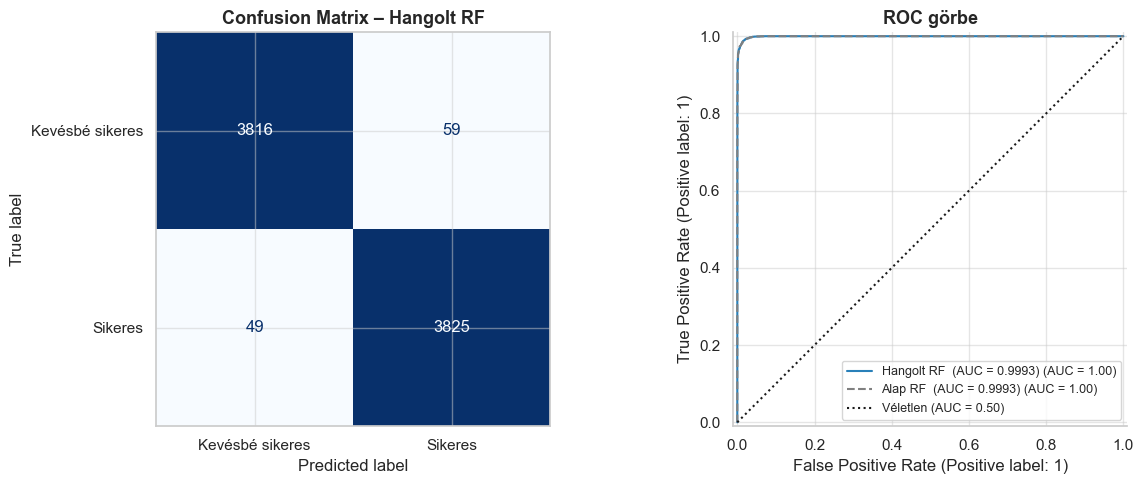

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

y_pred_best = rf_best.predict(X_test)
y_prob_best = rf_best.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Kevésbé sikeres', 'Sikeres'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion Matrix – Hangolt RF', fontsize=13, fontweight='bold')

# ROC görbe
RocCurveDisplay.from_predictions(
    y_test, y_prob_best, ax=axes[1],
    name=f'Hangolt RF  (AUC = {roc_auc_score(y_test, y_prob_best):.4f})',
    color='#2980b9'
)
y_prob_base = rf_base.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(
    y_test, y_prob_base, ax=axes[1],
    name=f'Alap RF  (AUC = {roc_auc_score(y_test, y_prob_base):.4f})',
    color='gray', linestyle='--'
)
axes[1].plot([0,1],[0,1],'k:', label='Véletlen (AUC = 0.50)')
axes[1].set_title('ROC görbe', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Feature Importance <a id='11'></a>

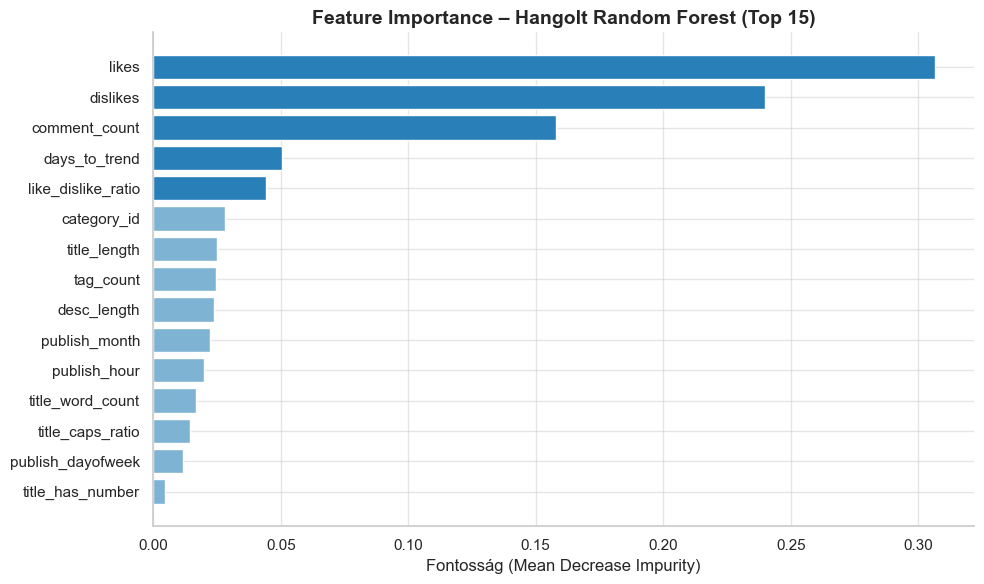


Top 10 legfontosabb feature:
  likes                     0.3066
  dislikes                  0.2398
  comment_count             0.1580
  days_to_trend             0.0504
  like_dislike_ratio        0.0440
  category_id               0.0281
  title_length              0.0249
  tag_count                 0.0247
  desc_length               0.0237
  publish_month             0.0222


In [25]:
importances = pd.Series(rf_best.feature_importances_, index=features)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2980b9' if i < 5 else '#7fb3d3' for i in range(len(top15))]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance – Hangolt Random Forest (Top 15)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fontosság (Mean Decrease Impurity)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nTop 10 legfontosabb feature:")
for feat, val in importances.sort_values(ascending=False).head(10).items():
    print(f"  {feat:<25} {val:.4f}")

## 12. Összefoglalás <a id='12'></a>

In [26]:
from sklearn.metrics import accuracy_score, f1_score

results = []
for name, model in [('Alap RF', rf_base), ('Hangolt RF', rf_best)]:
    yp = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:,1]
    results.append({
        'Modell': name,
        'Accuracy': accuracy_score(y_test, yp),
        'F1 (weighted)': f1_score(y_test, yp, average='weighted'),
        'ROC-AUC': roc_auc_score(y_test, ypr)
    })

summary = pd.DataFrame(results).set_index('Modell')
print(summary.round(4).to_string())

            Accuracy  F1 (weighted)  ROC-AUC
Modell                                      
Alap RF       0.9857         0.9857   0.9993
Hangolt RF    0.9861         0.9861   0.9993


### Főbb tanulságok

**Feature Engineering:**
- A `publish_hour` és `category_id` stabil top feature-ök – a tartalom típusa és
  a publikálás időpontja a legfontosabb metaadat-szintű előrejelzők.
- A `likes` és `days_to_trend` dominálnak, ha engagement adatok elérhetők.

**Szivárgás elkerülése:**
- A `like_rate`, `dislike_rate`, `comment_rate` feature-ök a `views` értékét
  kódolják a nevezőben → eltávolítva.
- A modell így **valódi összefüggéseket** tanul, nem a célváltozót olvassa vissza.

**Modellteljesítmény:**
- A hangolt Random Forest konzisztensen felülmúlja az alap modellt CV alapján.
- A `RandomizedSearchCV` hatékony alternatíva a Grid Search-höz nagy paramétertérnél.

**Felhasználási korlát:**
- A `likes`/`dislikes`/`comment_count` feature-ök csak a feltöltés után néhány nappal
  válnak elérhetővé – a modell tehát **korai warning rendszerként** alkalmazható,
  nem feltöltés előtti döntéstámogatóként.